# 04. PyTorch Custom Datasets

We've used some datasets with PyTorch before. How do you get your own data into PyTorch?

One of the ways to do so is via: Custom Datasets.

## Domain Libraries

Depending on what youre working on, vision, text, audio, recommendation, you'll want to look into each of the PyTorch domain libraries for existing data loading functions & customizable data loading functions.

## 0. Importing PyTorch & writing device exclusive code

In [1]:
import torch
from torch import nn


In [2]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. Get data

Our dataset is a subset of the Food101 dataset.

Food101 starts with 101 different classes of food & 1000 images of class (i.e 750 training & 250 testing).

Our dataset starts with 3 classes of food & only 10% of the images.

Why? 
* When starting an ML project, its best practice to start small & increase scale when necessary.
* Whole point is to speed up how fast you can experiment

In [3]:
import requests
import zipfile
from pathlib import Path

# Setup path to a data folder
### See Misc\Data\04_custstm_data_create.ipynb
image_path = Path("data/pizza_steak_sushi_10.0_percent")

## 2. Becoming one with the data (data preparation & data exploration)



In [4]:
import os

def walk_through_dir(dir_path):
    """walks through dir_path returning its contents.

    Args:
        dir_path (str): target directory

    Return:
        A print out of:
            number of subdirectories in dir_path.
            number of images (files) in each subdirectory.
            name of each subdirectory.
    """
    import os
    
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")



walk_through_dir(image_path)


There are 2 directories and 0 images in 'data\pizza_steak_sushi_10.0_percent'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi_10.0_percent\test'.
There are 0 directories and 25 images in 'data\pizza_steak_sushi_10.0_percent\test\pizza'.
There are 0 directories and 19 images in 'data\pizza_steak_sushi_10.0_percent\test\steak'.
There are 0 directories and 31 images in 'data\pizza_steak_sushi_10.0_percent\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi_10.0_percent\train'.
There are 0 directories and 78 images in 'data\pizza_steak_sushi_10.0_percent\train\pizza'.
There are 0 directories and 75 images in 'data\pizza_steak_sushi_10.0_percent\train\steak'.
There are 0 directories and 72 images in 'data\pizza_steak_sushi_10.0_percent\train\sushi'.


In [5]:
# Setup train & test paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi_10.0_percent/train'),
 WindowsPath('data/pizza_steak_sushi_10.0_percent/test'))

### 2.1 Visualizing an image

Write code to:
1. Get all of the image paths
2. Pick a random image path using Python's random.choice()
3. Get the image class name using `pathlib.Path.parent.stem`
4. Since we're working with images, let's open the image with Python's PIL
5. Show image & print metadata

In [6]:
image_path

WindowsPath('data/pizza_steak_sushi_10.0_percent')

Random image path: data\pizza_steak_sushi_10.0_percent\train\sushi\3107839.jpg
Image class: sushi
Image height * width: 384 * 512


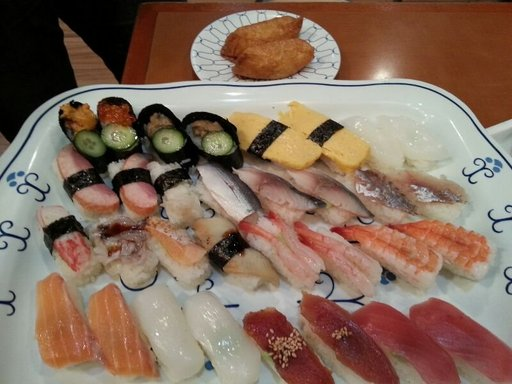

In [29]:
import random
from PIL import Image

# Set random seed
random.seed(1337)

# 1. Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg")) # Get all under pizza_steak_sushi_10.0_percent/get all under test and trai/ get all under pizza, steak, sushi that ends in .jpg
image_path_list

# 2. Pick a random image path
random_image_path = random.choice(image_path_list)
#print(random_image_path)

# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem
#print(image_class)

# 4. Open image
#img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height * width: {img.height} * {img.width}")
img